# RNN 語言模型

## 文字的處理

讀取 `data/shakespeare.txt` 文字檔的內容，並對檔案中的字元做基本統計與預覽，包含：

- 計算整份文字的總字元數
- 建立不重複字元的字元表
- 計算字元表大小
- 顯示字元表前 10 個字元
- 顯示原始文字前 148 個字元內容

In [21]:
# 指定要讀取的文字檔路徑
filename = 'data/shakespeare.txt'

# 讀取整個文字檔內容
data = open(filename, 'r').read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print ('字元總數 %d, 字符表的長度 %d unique.' % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print('字元表中的前 10 個字元：\n',chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print('前 148 個字元：\n',data[:148])

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['c', 'g', 't', 'Q', '3', 'X', 'v', 'B', ',', '!']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?



這段程式碼延續前面的字元表處理結果，進一步建立字元與索引之間的雙向映射，並定義一個 `one_hot_idx` 函式，將指定索引轉成 one-hot 向量表示。

這樣的做法是將字元改為量化後的數字，才能被電腦所處理。

In [22]:
import numpy as np

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = { ch:i for i,ch in enumerate(chars) }

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = { i:ch for i,ch in enumerate(chars) }

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print('字元到索引的映射：\n', char_to_idx)
print('索引到字元的映射：\n', idx_to_char)

def one_hot_idx(idx, vocab_size):  
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size)) 

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1  

    # 回傳 one-hot 向量
    return x

# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(char_to_idx['B'], vocab_size)

# 輸出測試結果
print('索引 %d 的 one-hot 向量：\n' % test_idx, one_hot_vector)

字元到索引的映射：
 {'c': 0, 'g': 1, 't': 2, 'Q': 3, '3': 4, 'X': 5, 'v': 6, 'B': 7, ',': 8, '!': 9, 'H': 10, 'b': 11, 'U': 12, 'x': 13, 'u': 14, ' ': 15, '\n': 16, ':': 17, 'w': 18, 'y': 19, 'R': 20, 'z': 21, 'Y': 22, 'a': 23, 'P': 24, 'p': 25, 'h': 26, 'i': 27, 'A': 28, 'S': 29, 'D': 30, 'T': 31, 'Z': 32, 'm': 33, 'n': 34, 'e': 35, 'k': 36, 'N': 37, 'O': 38, 's': 39, 'V': 40, 'M': 41, '.': 42, 'G': 43, 'K': 44, 'r': 45, '&': 46, 'E': 47, 'o': 48, 'l': 49, 'j': 50, 'd': 51, 'C': 52, 'W': 53, "'": 54, 'f': 55, 'L': 56, '-': 57, ';': 58, 'J': 59, '?': 60, 'I': 61, '$': 62, 'q': 63, 'F': 64}
索引到字元的映射：
 {0: 'c', 1: 'g', 2: 't', 3: 'Q', 4: '3', 5: 'X', 6: 'v', 7: 'B', 8: ',', 9: '!', 10: 'H', 11: 'b', 12: 'U', 13: 'x', 14: 'u', 15: ' ', 16: '\n', 17: ':', 18: 'w', 19: 'y', 20: 'R', 21: 'z', 22: 'Y', 23: 'a', 24: 'P', 25: 'p', 26: 'h', 27: 'i', 28: 'A', 29: 'S', 30: 'D', 31: 'T', 32: 'Z', 33: 'm', 34: 'n', 35: 'e', 36: 'k', 37: 'N', 38: 'O', 39: 's', 40: 'V', 41: 'M', 42: '.', 43: 'G', 44: 'K', 45: 

## 字元序列樣本採樣

這段程式碼定義了一個 `character_seq_data_iter_consecutive` 產生器函式，用來從文字資料中，以「連續切分」的方式產生訓練用序列批次資料。

它的主要用途是把原始字元序列切成多個 batch，並在每個 batch 中持續取出固定長度的序列片段，供序列模型訓練使用。每次輸出會同時提供：

- `X`：目前時間步的輸入序列
- `Y`：對應下一個字元的目標序列
- 是否為該輪第一個 batch 的標記值

In [23]:
import numpy as np

def character_seq_data_iter_consecutive(data, batch_size, seq_len,start_range=10):
      # 每次從 data 的隨機起始偏移位置開始取樣，讓不同 epoch 的樣本切法有所變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch 區塊可分配到的有效資料長度
    block_len = (len(data)-start-1) // batch_size

    # 計算每個區塊最多可以連續切出幾個長度為 seq_len 的批次
    num_batches = block_len // seq_len

    # 建立每個 block 的起始位置
    bs = np.array(range(0,block_len*batch_size,block_len) )

    # 可實際使用的總序列長度
    i_end = num_batches * seq_len

    # 依序取出每一段長度為 seq_len 的連續序列
    for i in range(0, i_end, seq_len): # 一個 block 的序列開始位置
        s = start+i                    # 目前在單一 block 內的起始位置

        # 建立輸入序列 X 與目標序列 Y
        X = np.empty((seq_len,batch_size),dtype=object)
        Y = np.empty((seq_len,batch_size),dtype=object)

        # 逐一填入 batch 中每個樣本的序列內容
        for b in range(batch_size): # b 表示一個批次中的第幾個樣本
            s_b = s+bs[b]

            # 依時間步逐一填入輸入與對應下一步目標
            for t in range(seq_len):
                X[t,b] = data[s_b]
                Y[t,b] = data[s_b+1]
                s_b +=1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為新一輪起始
        if i==0:
            yield X,Y,True
        else:
            yield X,Y,False

測試這個資料產生器是否能正確產生序列批次資料。

In [24]:
# 建立測試用字串資料
x = 'Li,where are you from'

# 設定每個 batch 的樣本數
batch_size = 2

# 設定序列長度（每個樣本的時間步長）
seq_length  = 3

# 建立連續序列資料迭代器
data_it = character_seq_data_iter_consecutive(x, batch_size, seq_length, 1)

# 用來控制只觀察前幾個 batch
i = 0 

# 逐批從資料迭代器取出序列資料
for x,y,_ in data_it:

    # 印出輸入序列
    print("x:",x)

    # 印出對應的目標序列（下一個字元）
    print("y",y)

    # 批次計數
    i+=1

    # 只顯示前兩個 batch
    if i==2:break

x: [['L' 'r']
 ['i' 'e']
 [',' ' ']]
y [['i' 'e']
 [',' ' ']
 ['w' 'y']]
x: [['w' 'y']
 ['h' 'o']
 ['e' 'u']]
y [['h' 'o']
 ['e' 'u']
 ['r' ' ']]


這段程式碼將先前的連續序列資料產生器進一步擴充，讓輸入 `X` 直接轉成 one-hot 編碼格式，並將目標 `Y` 轉成對應字元索引，方便後續直接拿來做字元級序列模型訓練。


In [25]:
def character_seq_data_iter_consecutive(data, batch_size, seq_len, vocab_size, start_range=10):
      # 隨機決定本輪資料切分的起始偏移，讓不同 epoch 的切法略有變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    # -1 是因為標籤 Y 需要對應到下一個字元
    block_len = (len(data) - start - 1) // batch_size

    # 計算每個 block 最多可切出幾個完整的 seq_len 批次
    num_batches = block_len // seq_len

    # 建立每個 block 在原始資料中的起始偏移量
    bs = np.array(range(0, block_len * batch_size, block_len))

    # 可實際使用的總時間步數，避免超出完整批次範圍
    i_end = num_batches * seq_len

    # 依 seq_len 為單位，逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        # 本批次在原始資料中的起始位置
        s = start + i

        # X: 輸入序列，使用 one-hot 表示字元
        # shape = (seq_len, batch_size, vocab_size)
        X = np.empty((seq_len, batch_size, vocab_size), dtype=np.int32)

        # Y: 目標序列，儲存下一個字元的索引
        # shape = (seq_len, batch_size, 1)
        Y = np.empty((seq_len, batch_size, 1), dtype=np.int32)

        # 逐一處理 batch 中的每個樣本
        for b in range(batch_size):
            # 取得第 b 個 block 在本批次中的起始位置
            s_b = s + bs[b]

            # 依時間步填入輸入 X 與標籤 Y
            for t in range(seq_len):
                # 目前字元轉為索引後，再轉成 one-hot 向量作為輸入
                X[t, b, :] = one_hot_idx(char_to_idx[data[s_b]], vocab_size)

                # 下一個字元的索引作為預測目標
                Y[t, b, :] = char_to_idx[data[s_b + 1]]

                # 往下一個時間步前進
                s_b += 1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為起始批次
        if i == 0:
            yield X, Y, True
        else:
            yield X, Y, False

In [26]:
# 建立測試用字串
x = 'Li,where are you from'

# 設定 batch 大小（每個時間步同時處理的序列數量）
batch_size = 2

# 設定序列長度（每個樣本的時間步數）
seq_length  = 3

# 建立資料迭代器（generator）
data_it = character_seq_data_iter_consecutive(x, batch_size, seq_length, vocab_size, 1)

# 用來限制只印出前兩個 batch
i = 0

# 逐批讀取資料
for x, y, _ in data_it:
    # 印出輸入資料（one-hot 編碼後）
    print("x:", x)

    # 印出標籤資料（下一個字元的索引）
    print("y", y)

    # 記錄已讀取的 batch 數量
    i += 1

    # 只顯示前兩個 batch，避免輸出過多
    if i == 2:
        break

x: [[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]
y [[[27]
  [35]]

 [[ 8]
  [15]]

 [[18]
  [19]]]
x: [[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

這段程式碼主要是在初始化一個 RNN（Recurrent Neural Network）的基本運行環境，包含模型參數與初始隱藏狀態（hidden state）。透過自定義模組 `modules.rnn`（別名 `fr`）來建立 RNN 所需的權重與狀態。

- 設定 RNN 的基本超參數（input/output 維度、hidden size、batch size）
- 呼叫自定義函式初始化模型參數（weights / biases）
- 初始化 RNN 的隱藏狀態，用於序列運算起點

In [27]:
import numpy as np
import modules.rnn as fr  # 匯入自定義 RNN 模組，並使用 fr 作為別名

# ===== 基本參數設定 =====
batch_size = 1           # 每次輸入的樣本數（batch size）
input_dim = vocab_size   # 輸入維度，通常為詞彙表大小（one-hot 或 embedding 前）
output_dim = vocab_size  # 輸出維度，對應詞彙預測空間
hidden_size = 100        # RNN 隱藏層維度（hidden state 大小）

# ===== 初始化 RNN 參數 =====
# 包含權重矩陣與偏置項（實際內容由 modules.rnn 決定）
params = fr.rnn_params_init(input_dim, hidden_size, output_dim)

# ===== 初始化 hidden state =====
# 建立初始隱藏狀態，通常為全 0，shape 為 (batch_size, hidden_size)
H = fr.rnn_hidden_state_init(batch_size, hidden_size)

這段程式碼實作了 RNN 前向傳播的兩個層次：單一步驟的前向計算，以及整段序列的前向計算。`rnn_forward_step` 負責處理單一時間步的輸入與前一個 hidden state，產生目前時間步的 hidden state 與輸出；`rnn_forward_` 則負責逐步走訪整個輸入序列，收集每個時間步的輸出與 hidden state。

In [28]:
def rnn_forward_step(params,X, preH):
    # 由參數列表中取出各權重矩陣與偏置項
    Wx, Wh, bh, Wf, bf = params

    # 計算目前時間步的 hidden state
    # 結合目前輸入 X 與前一個 hidden state preH，再經過 tanh 活化
    H = np.tanh(np.dot(X, Wx) + np.dot(preH, Wh) + bh)

    # 依據目前 hidden state 計算輸出值
    F = np.dot(H, Wf) + bf

    # 回傳目前時間步的輸出與 hidden state
    return F, H

def rnn_forward_(params,Xs, H_):
    # 由參數列表中取出各權重矩陣與偏置項
    Wx, Wh, bh, Wf, bf = params

    # 使用傳入的初始 hidden state 作為序列起點
    H = H_

    # Fs 用來依序儲存每個時間步的輸出
    Fs = []

    # Hs 用來記錄每個時間步的 hidden state
    Hs = {}

    # 保留初始 hidden state，方便後續追蹤前一時刻狀態
    Hs[-1] = np.copy(H)

    # 逐一處理整段輸入序列
    for t  in range(len(Xs)):
        # 取得目前時間步的輸入
        X = Xs[t]

        # 執行單一步驟的前向傳播，更新輸出與 hidden state
        F,H = rnn_forward_step(params,X,H)

        # 紀錄目前時間步的輸出
        Fs.append(F)

        # 紀錄目前時間步的 hidden state
        Hs[t] = H

    # 回傳整段序列的輸出與所有 hidden state
    return Fs, Hs

這段程式碼實作的是 RNN 的文字生成流程，根據給定的前綴字串 `prefix`，逐步預測後續字元，總共額外生成 `n` 個時間步的內容。函式會先將前綴的第一個字元作為起始輸入，接著在每個時間步中，使用前一個輸出的字元作為下一步輸入，透過 RNN 前向計算取得輸出分數，再轉成機率分佈做抽樣，產生下一個字元。

In [29]:
def predict_rnn(params,prefix,n): 
    # 由參數列表中取出 RNN 權重與偏置
    Wx, Wh,bh, Wf,bf =  params

    # Wxh, Whh,Why, bh, by =params["Wxh"],params["Whh"],params["Why"],params["bh"],params["by"]

    # 由權重矩陣形狀取得詞彙大小與 hidden state 維度
    vocab_size,hidden_size = Wx.shape[0],Wh.shape[1]

    # 初始化 batch size = 1 的 hidden state
    h = fr.rnn_hidden_state_init(1,hidden_size) 
    
    # 先將 prefix 的第一個字元作為起始輸出
    output = [char_to_idx[prefix[0]]]
   
    # 依 prefix 長度與欲生成長度，逐步往後預測
    for t in range(len(prefix) +n - 1):        
        # 將上一時間步的輸出作為目前時間步的輸入
        x = one_hot_idx(output[-1], vocab_size)
        
        # 執行單一步驟前向傳播，取得輸出分數與新的 hidden state
        z,h = rnn_forward_step(params,x,h) 
        
        # h = np.tanh(np.dot(x,Wx) + np.dot(h,Wh) + bh)
        # z = np.dot(h,Wf) + bf   
           
        # 在 prefix 範圍內時，直接使用 prefix 的下一個字元
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            # 將輸出分數轉為機率分佈
            p = np.exp(z) / np.sum(np.exp(z)) 

            # idx = int(p.argmax(axis=1))

            # 依機率分佈隨機抽樣下一個字元索引
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)
     
    # 將索引序列轉回字元並組成最終字串
    return ''.join([idx_to_char[i] for i in output])

In [30]:
str = predict_rnn(params,"he",200)
print(str)

heOcyrzvui? M$jlUu
:vppUFbtBbTm wcOjTmOZlGcaeNq-ug
iiH
DdXNv
E
3!'lwmg.BOHJb
VeB-t,k!KOzlQO cdRDrHjzVbo:Xe$SGPHFZfZVDIItkgvw&BgWmRv'k'X JBMtJf-bANniQR?lSakefHqznEPtM$oeIGmEV;REbPSaaLHEKp&,nlJA!.YKsPDowV


這段程式碼實作的是 RNN 單一訓練 epoch 的主要流程。函式會從資料迭代器 `data_iter` 逐批取得輸入序列與對應標籤，依序執行 hidden state 初始化、前向傳播、loss 計算、反向傳播與參數更新，並在訓練過程中記錄每次迭代的 loss。最後會回傳整個 epoch 的 loss 紀錄，以及目前保留下來的 hidden state。

In [31]:
def rnn_train_epoch(params,data_iter,optimizer,iterations,loss_function,print_n=100):
    # 由參數列表中取出 RNN 權重與偏置
    Wx, Wh,bh, Wf,bf = params

    # 紀錄每次迭代的 loss
    losses = []

    # 迭代計數器
    iter = 0

    # 由 hidden-to-hidden 權重矩陣取得 hidden state 維度
    hidden_size = Wh.shape[0]

    # 逐批讀取訓練資料
    for Xs,Ys,start in data_iter:

        # 由目前 batch 的第一個時間步輸入推得 batch size
        batch_size = Xs[0].shape[0]

        # 若為新序列起點，則重新初始化 hidden state
        if start:
            H = fr.rnn_hidden_state_init(batch_size,hidden_size)

        # 執行前向傳播，取得各時間步輸出與 hidden state
        Zs,Hs = fr.rnn_forward(params,Xs,H)

        # 計算 loss，並取得對輸出層的梯度
        loss,dzs = loss_function(Zs,Ys)

        # 除錯用輸出，目前不執行
        if False:
            print("Z.shape",Zs[0].shape)
            print("Y.shape",Ys[0].shape)
            print("H",H.shape)

        # 執行反向傳播，取得各參數梯度
        dWx, dWh, dbh,dWf, dbf = fr.rnn_backward(params,Xs,Hs,dzs)

        # 取出最後一個時間步的 hidden state，供下一批次延續使用
        H = Hs[len(Hs)-2]    #最后时刻的隐状态向量

        # 整理梯度列表，交由 optimizer 更新參數
        grads = [dWx, dWh, dbh,dWf, dbf]
        optimizer.step(grads)

        # 紀錄目前 loss
        losses.append(loss)

        # 每隔固定次數輸出目前訓練資訊
        if iter % print_n == 0:
            print ('iter %d, loss: %f' % (iter, loss))

        iter+=1

        # 達到指定迭代數後停止
        if iter>iterations:break

    # 回傳整個 epoch 的 loss 紀錄與最後保留的 hidden state
    return losses,H

這段程式碼是在設定並執行 RNN 的訓練流程，包含模型參數初始化、loss function 與 optimizer 設定、依 epoch 反覆訓練，以及最後將所有訓練過程中的 loss 畫成曲線。整體來看，這是模型訓練主流程的外層控制段落，負責串接前面定義好的資料迭代器、訓練函式與視覺化結果。

iter 0, loss: 104.359074
iter 10, loss: 97.460504
iter 20, loss: 84.553379
iter 30, loss: 75.813632
iter 40, loss: 80.097364
iter 50, loss: 83.306465
iter 60, loss: 85.126040
iter 70, loss: 77.021451
iter 80, loss: 74.822311
iter 90, loss: 73.029579
iter 100, loss: 68.858495
iter 110, loss: 73.656032
iter 120, loss: 70.369021
iter 130, loss: 75.542457
iter 140, loss: 69.731996
iter 150, loss: 70.053069
iter 160, loss: 68.559608
iter 170, loss: 71.245968
iter 180, loss: 73.119445
iter 190, loss: 66.231513
iter 200, loss: 67.911938
iter 210, loss: 64.089915
iter 220, loss: 73.170738
iter 230, loss: 57.879848
iter 240, loss: 62.660229
iter 250, loss: 74.822728
iter 260, loss: 61.932496
iter 270, loss: 62.064105
iter 280, loss: 57.840699
iter 290, loss: 77.389139
iter 300, loss: 59.958873
iter 310, loss: 65.417199
iter 320, loss: 60.166393
iter 330, loss: 62.014237
iter 340, loss: 65.799008
iter 350, loss: 65.605809
iter 360, loss: 63.452717
iter 370, loss: 61.987104
iter 380, loss: 61.036

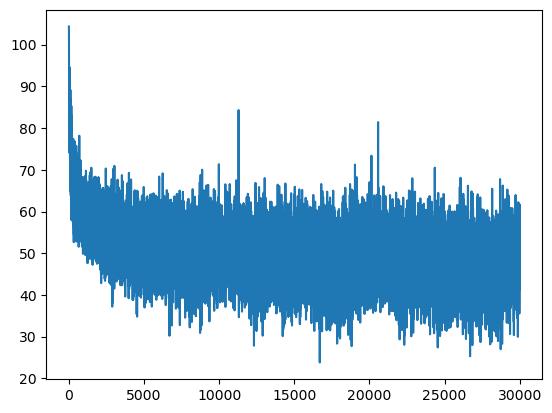

In [32]:
import matplotlib.pyplot as plt

# ===== 模型與資料維度設定 =====
batch_size = 3
input_dim = vocab_size
output_dim= vocab_size
hidden_size=100

# 初始化 RNN 參數
params = fr.rnn_params_init(input_dim, hidden_size,output_dim)

# 初始化 hidden state
H = fr.rnn_hidden_state_init(batch_size,hidden_size)

# 每段序列的時間步長度
seq_length = 25

# ===== loss function 設定 =====
# 將 loss 計算函式包成可直接傳入訓練流程的形式
loss_function = lambda F,Y:fr.rnn_loss_grad(F,Y) #,util.loss_grad_least)

# ===== 訓練超參數設定 =====
epoches = 3
learning_rate = 1e-2
iterations  =10000

# 用來累積所有 epoch 的 loss
losses = []

# ===== optimizer 設定 =====
optimizer = fr.AdaGrad(params,learning_rate)

momentum = 0.9
optimizer = fr.SGD(params,learning_rate,momentum)

# ===== 開始訓練 =====
for epoch in range(epoches):
    # 建立連續式序列資料迭代器
    data_it =  character_seq_data_iter_consecutive(data,batch_size,seq_length,vocab_size,100)

    # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)

    # 執行單一 epoch 訓練，取得該 epoch 的 loss 紀錄與最後 hidden state
    epoch_losses,H = rnn_train_epoch(params,data_it,optimizer,iterations,loss_function,print_n=10)

    # 將本次 epoch 的 loss 加入總 loss 紀錄
    losses.extend(epoch_losses)

    # epoch_losses = np.array(epoch_losses).mean()
    # losses.append(epoch_losses)

# ===== 繪製訓練 loss 曲線 =====
plt.plot(losses[:])

In [34]:
str = predict_rnn(params,"he",200)
print(str)

her otsich,
blore, bot lince goate as, oorels is blorging of blook of rude,
For
Wame your pruay.

GUtERDY VI:
How of Grane dlouser, we preas, and your coten wafe
With offer a hippar hun becoupa unfaingt
